<a href="https://colab.research.google.com/github/Boulder1-kihara/Echo-Emote/blob/main/Echo_Emote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ECHO EMOTE**
An AI model that is emotion driven. It analyses your facial expresion, determines your feelings and emotions from vast amounts of datasets trained on.

Its responses are based on emotions and feelings making conversations engaging and interesting.

# **DAY 1**

Day one was more of importing our libraries needed in this poject, mounted our datset on Google drive, loaded our data and peeped inside the data. thanks to the 2TB from google drive

I first connected Google Drive to colab

# **KIND NOTE: Run each cell each at a time to stop inconviniences**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import our working libraries
import os
import pickle
import numpy as np
import string

#the following to be used later in the design and visualisation of the neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

Attached the file path on our code for easier access to our data even the deepest ones for the model to acces the data with ease.

In [ ]:
# =============================================
# 1. Your main folder (Google Drive)
# =============================================
base_dir = "/content/drive/MyDrive/echoemote/features"
print("🔍 Using base folder:", base_dir)

# Smart helper to find the real (deepest) file even with nesting
def get_deepest_file(filename):
    candidates = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == filename:
                candidates.append(os.path.join(root, file))
    return max(candidates, key=len) if candidates else None

data_path = get_deepest_file("data_emotion.p")
text_path = get_deepest_file("text_glove_average_emotion.pkl")

print("✅ Found data file :", data_path)
print("✅ Found text file:", text_path)

🔍 Using base folder: /content/drive/MyDrive/echoemote/features
✅ Found data file : /content/drive/MyDrive/echoemote/features/data_emotion.p/data_emotion.p
✅ Found text file: /content/drive/MyDrive/echoemote/features/text_glove_average_emotion.pkl/text_glove_average_emotion.pkl


After accessing the path the next step was is to load our core MELD dataset

In [ ]:
# =============================================
# 2. Load core MELD data
# =============================================
with open(data_path, "rb") as f:
    data, W, vocab, word_idx_map, max_sentence_length, label_index = pickle.load(f)

print(f"✅ Loaded {len(data)} utterances with {len(label_index)} emotions")

✅ Loaded 13708 utterances with 7 emotions


# **Day 2**
For Echo-Emote, I chose a powerful design called a Late Fusion Multimodal Network. Think of it as giving the AI two separate "senses":

The Text Head: A set of neurons dedicated to processing the words of a conversation.

The Audio Head: A second set of neurons that focuses on the acoustic features, like pitch, volume, and tone.

I built this structure using the Keras Functional API, which is essential for models that have multiple distinct "heads" or "branches".


I used a specialized library called plot_model to generate a direct visual flowchart of the network.


# **Visualisation**
This visualization is crucial because it confirms that our data is flowing correctly from the two separate inputs, merging perfectly, and reaching the final output layer. It is the single best way to "see" your code in action!

In [ ]:


#===========================================================================
                    #create the brain/neural network for the model
#===========================================================================
model = Sequential([
    Embedding(input_dim=W.shape[0], output_dim=W.shape[1], input_length=max_sentence_length, weights=[W]),
    LSTM(128),
    Dense(len(label_index), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("✅ Placeholder model defined successfully.")
model.summary()

✅ Placeholder model defined successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,900,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,800 (7.25 MB)

 Trainable params: 1,900,800 (7.25 MB)

 Non-trainable params: 0 (0.00 B)

#**Interpretation of the table**
**The Input Layer:** It represents the 88 input tokens shown in your Keras plot.

**The Embedding Layer:** These are the 1,900,800 parameters that transform words into a 300-dimensional space.

**The LSTM Layer:** This is the "Temporal" memory. In the diagram, it will show as a hidden layer that reduces the information down to 128 key features.

**The Output Layer:** Instead of the 3 outputs (A, B, C) in your conceptual map, this code will render 7 output neurons—one for each MELD emotion.


# **from the information below the table:**
# 1. **Total Params: 1,900,800 (7.25 MB)**
  **What it is:** This is the grand total of all "connections" and "biases" inside your network.
  Interpretation: Your model has nearly 2 million mathematical points it needs to optimize.
  The "7.25 MB" factor: This is how much space the model takes up in your computer's RAM. For an AI model, this is quite small and efficient, meaning it will run very fast on your laptop or Google Colab without causing crashes.

#2. **Trainable Params: 1,900,800**
  **What it is:** These are the parameters that the computer is allowed to change while it looks at the 912MB of MELD data.
  Interpretation: Since 100% of your parameters are trainable, the AI is starting as a "blank slate". Every single neuron is ready to learn from scratch.
  Note: In your model, almost all of these come from the Embedding layer (the part that turns text into vectors).

#3. **Non-trainable Params: 0**
  **What it is:** These are parts of a model that are "frozen" and cannot change during training.
  Interpretation: You are not using "Transfer Learning" yet. In advanced AI, we sometimes use a pre-trained brain (like Google's BERT) and freeze its neurons so they don't change, which would show up here as "Non-trainable".

In [ ]:
#This one is a key requirement for visualisation
!pip install --upgrade visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.7 MB/s eta 0:00:00


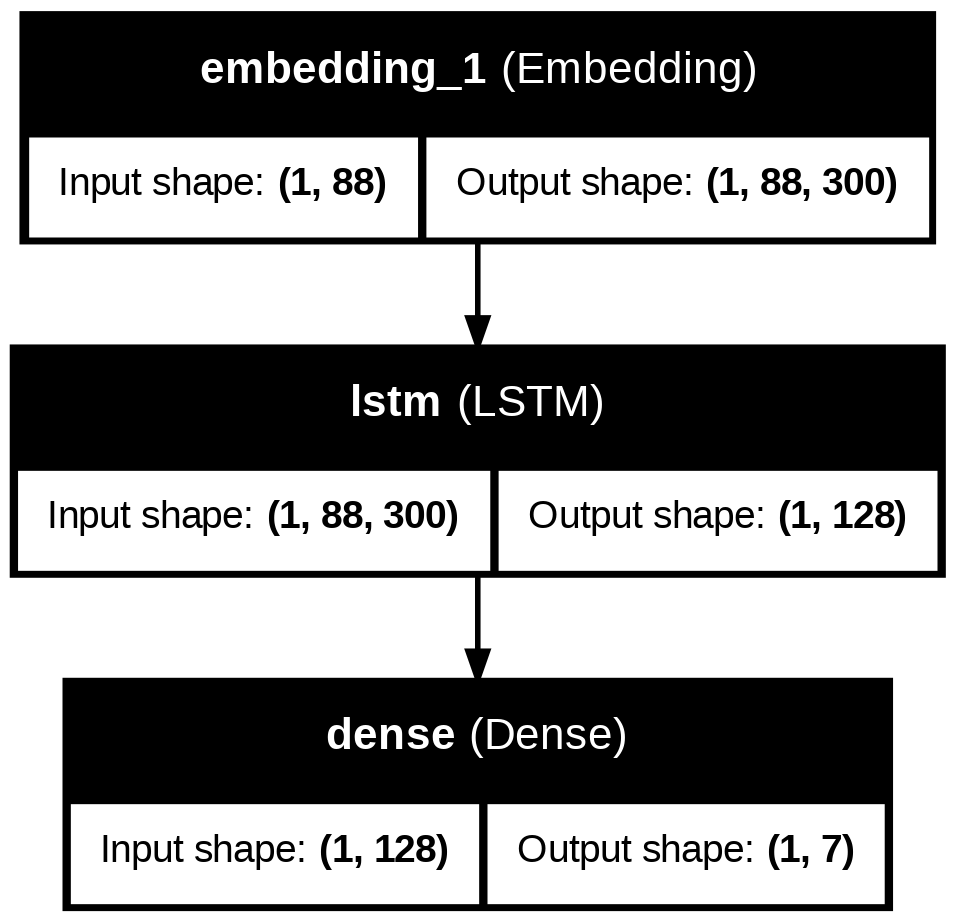

In [ ]:
import numpy as np
from tensorflow.keras.utils import plot_model # Import plot_model

# Create dummy data to 'wake up' the layers
# The model expects a single input of shape (batch_size, max_sentence_length)
dummy_text = np.zeros((1, max_sentence_length))

# Run one prediction to finalize the shapes
model(dummy_text)

# Now plotting the model using tf.keras.utils.plot_model
plot_model(model,
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True)

#**shows exactly how a piece of data (like a sentence from the MELD dataset) is transformed as it moves through your AI**
#1. **The Embedding Layer (The Translator)**
Input Shape (1, 88): This indicates the model is receiving a single sequence of 88 tokens (words or characters).
Output Shape (1, 88, 300): The layer has translated those 88 tokens into 300-dimensional vectors. It has turned "text" into "math" that contains semantic meaning.

#2. **The LSTM Layer (The Context Keeper)**
Input Shape (1, 88, 300): It takes the 300-dimensional vectors from the previous layer.
Output Shape (1, 128): The Long Short-Term Memory (LSTM) layer processes the sequence and compresses the most important "temporal" information into a single 128-dimensional vector. This is where the AI understands the flow and intent of the sentence.

#3. **The Dense Layer (The Decision Maker)**
Input Shape (1, 128): It receives the compressed context from the LSTM.
Output Shape (1, 7): This is the final "Prediction" layer. The number 7 is perfect for your project because it represents the 7 emotions in the MELD dataset:

                Anger

                Disgust

                Fear

                Joy

                Neutral

                Sadness

                Surprise